## Visual search

This notebook correlates VLM performances on the visual search task with the maximum similarity between concept vectors associated with the concepts involved.

In [1]:
model_name = 'qwen' #'qwen', 'intern' or 'gemma'

#### Import and utilities

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from ast import literal_eval # to get dict/list from csv
import hydra
import os
import matplotlib.pyplot as plt
from scipy import stats
import glob

import pyrootutils,sys
pyrootutils.setup_root('.',cwd=True,pythonpath=False)
sys.path.append('./src')

In [3]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize("config")
cfg = hydra.compose("activations_gen", overrides=[dict(qwen='+experiment=bal_qwen7b',
                                                       intern='+experiment=bal_internvl8b',
                                                       gemma='+experiment=bal_gemma12b')[model_name],
                                                  'probe=attn_single'
                                                  ])
probelabel = 'mmp' #layer used to read hidden activations (defined in config)

/tmp/ipykernel_3460903/165392830.py:2: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize("config")


In [4]:
colors=cfg.dataset.COLORS.copy()
shapes=cfg.dataset.SHAPES.copy()
marker_shapes = ["\U000025A0","\U000025B2","\U000025CF","\U00002B1F","\U00002605","\U00002764"]

def simmatrix(V):
  'returns a matrix of cosine similarities'
  n=V.shape[0]
  sims = torch.empty(n,n)
  for i in range(n):
    sims[i]=torch.cosine_similarity(V,V[i])
  return sims

def comp_simmatrix(V):
  if not isinstance(V, torch.Tensor):
      V = torch.from_numpy(V) 
  'returns a matrix of cosine similarities'
  n=V.shape[0]
  sims = torch.empty(n,n)
  for i in range(n):
    sims[i]=torch.cosine_similarity(V,V[i])
  return (sims.numpy()+1)/2

In [5]:
cs_to_id = {} # go from 'redsquare' to 0, etc. (0-36)
for i,c in enumerate(colors):
  for j,s in enumerate(shapes):
    cs_to_id[c+s]=i*6+j

### Read VLM output CSVs

In [6]:
outputdir = cfg.probe.outputs_path+'_test'
all_files = sorted( glob.glob(os.path.join(outputdir , "metadata*.csv")) )
metas = []
for filepath in (all_files):
  metas.append(pd.read_csv(filepath, 
                        dtype={'ID': 'string'}, 
                        converters={'target_pos': literal_eval, 
                                    'distractors': literal_eval}
              ))
metadf = pd.concat(metas,ignore_index=True).sort_values('ID')

In [7]:
metadf['isright'].value_counts(normalize=True)

isright
True     0.863426
False    0.136574
Name: proportion, dtype: float64

### Load concept vectors and compute similarities

In [8]:
conc_vectors = torch.load(os.path.join('.','outputs',cfg.model.model_name,
                              'colorshape_cv_centroid.pt')) 

In [9]:
sims = comp_simmatrix(conc_vectors)

In [10]:
## Collect similarities with all distractors for each image
all_sims = []
i=0
for tup in metadf.itertuples():
  tupsims = []
  target_id = cs_to_id[tup.target_color+tup.target_shape]
  for dist in tup.distractors[tup.has_target:]:
    dist_id = cs_to_id[dist['color']+dist['shape']]
    tupsims.append(sims[dist_id,target_id].item())
  all_sims.append(tupsims)
max_sims = np.array([np.max(s) for s in all_sims])

In [11]:
metadf['max_sims'] = max_sims

### Plot correlation

In [12]:
def verify_and_plot(mname, df, n_bins=10, top_col='max_sims'):
    # 1. Prepare Data & Split
    df = df.copy()
    # Force numeric
    df[[top_col, 'isright']] = df[[top_col, 'isright']].apply(pd.to_numeric, errors='coerce')
    
    results = []

    conditions = [('Present', True, 'darkorange'), ('Absent', False, 'royalblue')]
    
    # 2. Process Each Condition
    for name, target_status, _ in conditions:
        subset = df[df['has_target'] == target_status].copy()
        
        # Binning (using TOP_sim for BOTH as requested)
        try:
            subset['bin'] = pd.qcut(subset[top_col], q=n_bins, labels=False) + 1
        except ValueError:
            continue
            
        # Aggregate with SEM
        agg = subset.groupby('bin').agg(
            mean_sim=(top_col, 'mean'),
            mean_acc=('isright', 'mean'),
            sem_acc=('isright', 'sem'), # Needed for error bars
            count=('isright', 'count')
        ).reset_index()
        
        agg['condition'] = name
        results.append(agg)
        
    final_df = pd.concat(results)

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(4, 3))
    plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})
    
    for name, _, color in conditions:
        data = final_df[final_df['condition'] == name]
        if data.empty: continue
        
        X = data['mean_sim']
        Y = data['mean_acc']
        Y_err = data['sem_acc']
        
        # Correlation
        r, _ = stats.pearsonr(X, Y)
        
        # Errorbar Plot
        ax.errorbar(X, Y, yerr=Y_err, fmt='o', color=color, 
                    label=f"{name} (r={r:.2f})", markersize=8, 
                    capsize=4, linewidth=2, markeredgecolor='black')
        
        # Fit Line
        z = np.polyfit(X, Y, 1)
        ax.plot(X, np.polyval(z, X), '--', color=color, alpha=0.5)

    ax.set_xlabel('Most similar distractor')
    ax.set_ylabel('Accuracy')
    # ax.set_title(mname.capitalize())
    ax.legend(loc='lower left', frameon=True, fancybox=True, framealpha=0.9, edgecolor='gray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join('.','outputs','compositionality_plots',
                             "vsearch_"+mname+"_colorblind.pdf")) 
    return final_df

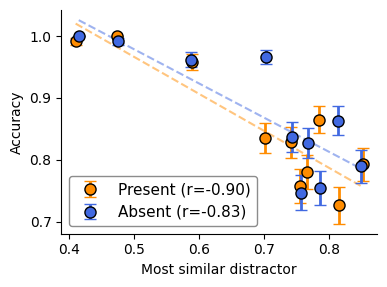

In [13]:
final_df = verify_and_plot(model_name, metadf, n_bins=10);

In [14]:
model_name

'qwen'